In [1]:
import os
import numpy as np
import tensorflow as tf

# Enable GPU memory growth to avoid full preallocation
gpus = tf.config.experimental.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("GPU memory growth error:", e)
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.mixed_precision.set_global_policy("mixed_float16")
# test

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA RTX A1000 6GB Laptop GPU, compute capability 8.6


In [2]:
# 1) Point to your root folder
# root = r"E:\mjosa\29\training_data\radiance"

# this is with pure sed vs dark spots.
root_original = r"E:\mjosa\29\training_data_new\fundation\reflectance"
root_augmented = r"E:\mjosa\29\training_data_new\fundation\augmented"


# 2) Gather all .npz paths and class names
file_paths = []
labels = []

for root in [root_original, root_augmented]:
    for transect in os.listdir(root):
        transect_path = os.path.join(root, transect)
        if not os.path.isdir(transect_path):
            continue
        for fname in os.listdir(transect_path):
            if not fname.lower().endswith(".npz"):
                continue
            if "_flip" in fname:  # augmented file
                base = fname.split("_flip")[0]
            else:
                base = fname.rsplit(".", 1)[0]
            label = base.split("_")[0]
            file_paths.append(os.path.join(transect_path, fname))
            labels.append(label)


# 3) Map class names to integer indices
class_names = sorted(set(labels))
label_to_idx = {c: i for i, c in enumerate(class_names)}
label_idxs = [label_to_idx[l] for l in labels]

print("Classes:", class_names)
print(f"Found {len(file_paths)} samples.")

Classes: ['dark', 'sediment']
Found 1640 samples.


In [3]:
train_paths, val_paths, train_idxs, val_idxs = train_test_split(
    file_paths, label_idxs, test_size=0.2, stratify=label_idxs, random_state=42
)
print(f"{len(train_paths)} train samples, {len(val_paths)} validation samples")

1312 train samples, 328 validation samples


In [4]:
def data_generator(paths, idxs, num_classes, batch_size=8, band_range=None):
    """
    paths       : list of .npz filenames
    idxs        : list of integer labels
    num_classes : total number of classes
    batch_size  : how many samples per batch
    band_range  : tuple (start, end) of bands to keep (Python‐style, end exclusive)
    """
    n = len(paths)
    order = np.arange(n)
    while True:
        np.random.shuffle(order)
        for start in range(0, n, batch_size):
            idxs_batch = order[start : start + batch_size]
            Xb, yb = [], []
            for i in idxs_batch:
                cube = np.load(paths[i])["data"].astype(
                    np.float16
                )  # shape (T, H, W, B)
                # --- here’s your slice: keep only bands [b0:b1) ---
                if band_range is not None:
                    b0, b1 = band_range
                    cube = cube[..., b0:b1]
                # now cube.shape == (T, H, W, b1-b0)
                Xb.append(
                    cube[..., np.newaxis]
                )  # adds a “channel” dim → (T,H,W, bands,1)
                yb.append(to_categorical(idxs[i], num_classes))
            yield np.stack(Xb, 0), np.stack(yb, 0)


batch_size = 8


num_classes = len(class_names)


band_range = (100, 150)


train_gen = data_generator(
    train_paths, train_idxs, num_classes, batch_size, band_range=band_range
)


val_gen = data_generator(
    val_paths, val_idxs, num_classes, batch_size, band_range=band_range
)


steps_per_epoch = len(train_paths) // batch_size


validation_steps = len(val_paths) // batch_size

In [5]:
# ── 5) Peek one batch for input_shape ────────────────────────────────────────
X0, y0 = next(train_gen)
input_shape = X0.shape[1:]  # (T, S, B, 1)
print("Input shape:", input_shape)

Input shape: (50, 968, 50, 1)


In [6]:
# # ── 6) Build & compile your model ───────────────────────────────────────────
# model = models.Sequential(
#     [
#         layers.Input(shape=input_shape),
#         layers.Conv3D(16, (3, 3, 3), activation="relu", padding="same"),
#         layers.MaxPooling3D((2, 2, 2)),
#         layers.Dropout(0.25),
#         layers.Conv3D(32, (3, 3, 3), activation="relu", padding="same"),
#         layers.MaxPooling3D((2, 2, 2)),
#         layers.Dropout(0.25),
#         layers.Flatten(),
#         layers.Dense(64, activation="relu"),
#         layers.Dropout(0.5),
#         layers.Dense(num_classes, activation="softmax"),
#     ]
# )
# model.compile(
#     optimizer=optimizers.Adam(), loss="categorical_crossentropy", metrics=["accuracy"]
# )
# model.summary()

In [7]:
from tensorflow.keras import layers, models, optimizers

model = models.Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv3D(8, (3, 3, 3), activation="relu", padding="same"),
        layers.MaxPooling3D((2, 2, 2)),
        layers.Conv3D(16, (3, 3, 3), activation="relu", padding="same"),
        layers.MaxPooling3D((2, 2, 2)),
        # global spatial+temporal pooling → shape = (batch, 16)
        layers.GlobalAveragePooling3D(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)
model.compile(
    optimizer=optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d (Conv3D)             (None, 50, 968, 50, 8)    224       
                                                                 
 max_pooling3d (MaxPooling3D  (None, 25, 484, 25, 8)   0         
 )                                                               
                                                                 
 conv3d_1 (Conv3D)           (None, 25, 484, 25, 16)   3472      
                                                                 
 max_pooling3d_1 (MaxPooling  (None, 12, 242, 12, 16)  0         
 3D)                                                             
                                                                 
 global_average_pooling3d (G  (None, 16)               0         
 lobalAveragePooling3D)                                          
                                                        

In [8]:
# ── 7) Set up EarlyStopping to avoid overfitting ────────────────────────────
early = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

In [9]:
# ── 8) Train with validation ─────────────────────────────────────────────────
history = model.fit(
    train_gen,
    epochs=100,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    callbacks=[early],
)

Epoch 1/100
 93/164 [================>.............] - ETA: 1:10 - loss: 0.6731 - accuracy: 0.6089

KeyboardInterrupt: 

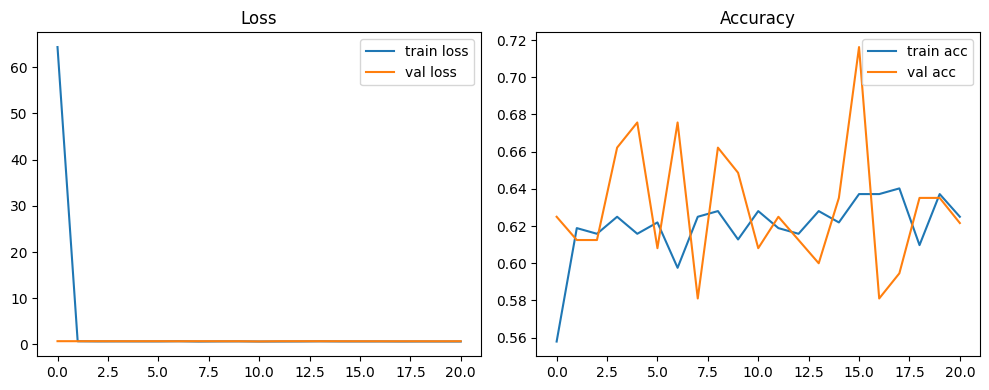

In [ ]:
# 1a) Loss curve
plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val   loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# 1b) Accuracy curve
plt.figure()
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val   acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

In [ ]:
model.save(r"E:\mjosa\29\cnn_models\model_early_stop_23_04.keras")

below is just alot of testing (can be deleted no problem), above is the only main code 

In [ ]:
import tensorflow as tf

# Check available physical devices
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))

# List all GPUs TensorFlow can see
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.10.0
Num GPUs Available: 1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import time, math
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

steps = math.ceil(len(val_paths) / batch_size)

y_true, y_pred = [], []
start = time.time()

for i, (Xb, yb) in enumerate(
    tqdm(
        data_generator(val_paths, val_idxs, num_classes, batch_size),
        total=steps,
        desc="Predicting",
        unit="batch",
        dynamic_ncols=True,
        leave=True,
    )
):
    preds = model.predict(Xb, verbose=0)
    y_true.extend(np.argmax(yb, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

    # Show ETA every 10 batches
    if i % 10 == 0 and i > 0:
        elapsed = time.time() - start
        avg_time = elapsed / (i + 1)
        remaining = (steps - (i + 1)) * avg_time
        print(f"ETA: {remaining / 60:.1f} min remaining")

# Final timing report
elapsed = time.time() - start
print(f"\n✅ Done in {elapsed:.2f} s ({len(val_paths) / elapsed:.1f} samples/s)")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues", interpolation="nearest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)
plt.colorbar()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Predicting:  27%|██▋       | 11/41 [00:17<00:48,  1.62s/batch]

ETA: 0.8 min remaining


Predicting:  51%|█████     | 21/41 [00:41<00:50,  2.52s/batch]

ETA: 0.7 min remaining


Predicting:  76%|███████▌  | 31/41 [01:08<00:25,  2.59s/batch]

...

ETA: -4.8 min remaining


Predicting: 221batch [06:11,  1.66s/batch]

ETA: -5.0 min remaining


Predicting: 226batch [06:21,  1.69s/batch]


KeyboardInterrupt: 

idk, below is some unsupervised just to test

Cluster 0: 277 samples
Cluster 1: 40 samples
Cluster 2: 219 samples
Cluster 3: 31 samples


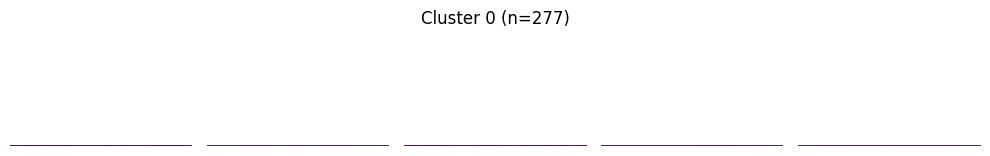

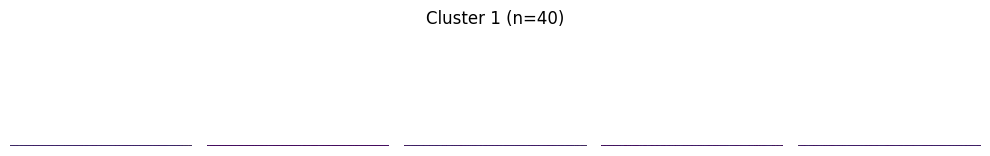

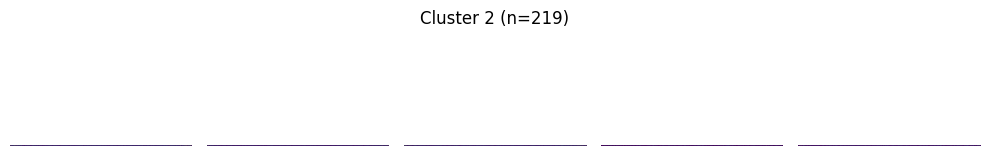

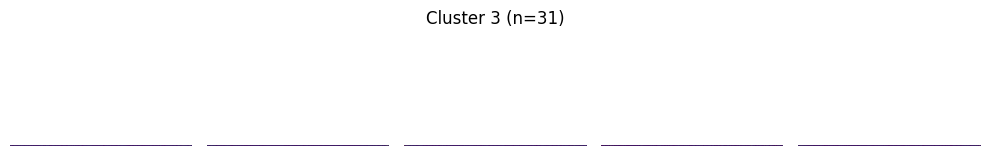

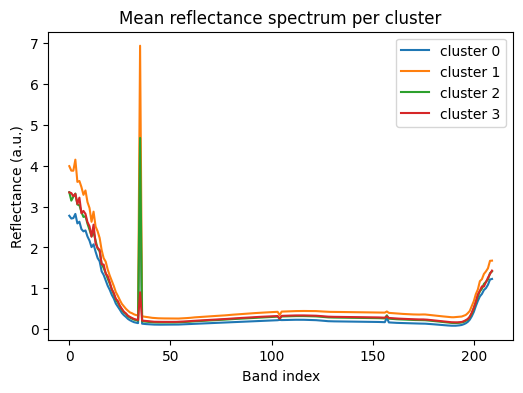

In [ ]:
# ── unsupervised_clustering.ipynb cell ──
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1) point this at your folder of .npz files
data_root = r"E:\mjosa\29\training_data\reflectance"


# 2) collect file paths and compute one feature vector per cube: the mean spectrum
file_paths = []
mean_spectra = []
for transect in os.listdir(data_root):
    folder = os.path.join(data_root, transect)
    if not os.path.isdir(folder):
        continue
    for fname in os.listdir(folder):
        if not fname.lower().endswith(".npz"):
            continue
        p = os.path.join(folder, fname)
        cube = np.load(p)["data"].astype(np.float16)  # shape (T, S, B)
        mean_spec = cube.mean(axis=(0, 1))  # average over T & S → (B,)
        mean_spectra.append(mean_spec)
        file_paths.append(p)

mean_spectra = np.stack(mean_spectra, axis=0)  # (N_samples, B)

# 3) optionally reduce dimensionality (denoise & speed up)
pca = PCA(n_components=10, random_state=0)
X = pca.fit_transform(mean_spectra)  # (N_samples, 10)

# 4) pick number of clusters
K = 4
kmeans = KMeans(n_clusters=K, random_state=0)
labels = kmeans.fit_predict(X)

# 5) report cluster sizes
for c in range(K):
    print(f"Cluster {c}: {np.sum(labels==c)} samples")

# 6) visualize a few examples per cluster
#    we’ll do a simple RGB composite by taking three bands,
#    and picking the middle time‐slice of the cube.
bands_rgb = [10, 30, 50]  # choose 3 band‐indices that look good as color
n_show = 5

for c in range(K):
    idxs = np.where(labels == c)[0]
    if len(idxs) == 0:
        continue
    fig, axes = plt.subplots(1, n_show, figsize=(n_show * 2, 2))
    fig.suptitle(f"Cluster {c} (n={len(idxs)})", y=1.1)
    for i, ax in enumerate(axes):
        if i >= len(idxs):
            break
        cube = np.load(file_paths[idxs[i]])["data"]
        # pick the middle time‐slice and composite bands → H×W×3
        tslice = cube.shape[0] // 2
        rgb_img = cube[tslice, ..., bands_rgb]
        ax.imshow((rgb_img - rgb_img.min()) / (rgb_img.ptp()))  # normalize
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# 7) plot each cluster’s mean spectrum
plt.figure(figsize=(6, 4))
for c in range(K):
    m = mean_spectra[labels == c].mean(axis=0)
    plt.plot(m, label=f"cluster {c}")
plt.legend()
plt.title("Mean reflectance spectrum per cluster")
plt.xlabel("Band index")
plt.ylabel("Reflectance (a.u.)")
plt.show()